In [3]:
#we start with importning libaries we will need

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
#load the data

df = pd.read_csv('hotel_bookings.csv')

# small look at the data 

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.shape

(119390, 32)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# data cleaning

In [9]:
# first we handle the nulls

# fill missing children with 0 (no children in booking)
df['children'] = df['children'].fillna(0)

In [10]:
# fill missing country with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# fill missing agent with 0 
df['agent'] = df['agent'].fillna(0)

# fill missing company with 0 
df['company'] = df['company'].fillna(0)

# confirm no more missing values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

# Encoding Categorical Variables

### we need to convert all text/categorical columns into numbers
#### first lets see which columns are text based

In [11]:
# check which columns are categorical
df.select_dtypes(include='object').columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [12]:
# reservation_status and reservation_status_date will be dropped, because reservation_status directly tells us if the booking was canceled or not
#  which is exactly what we are trying to predict, keeping it would be cheating, and reservation_status_date is just a date that adds no value to our prediction

df = df.drop(columns=['reservation_status', 'reservation_status_date'])

In [13]:
# now we convert all remaining categorical columns into numbers

le = LabelEncoder()

cat_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
            'distribution_channel', 'reserved_room_type', 'assigned_room_type',
            'deposit_type', 'customer_type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# confirm all columns are now numbers
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [14]:
df.dtypes

hotel                               int64
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                  int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                int64
country                             int64
market_segment                      int64
distribution_channel                int64
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                  int64
assigned_room_type                  int64
booking_changes                     int64
deposit_type                        int64
agent                             

# scaling the columuns

### we will scale only (lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights'), and thats because lead_time can go up to 700+ days, very big range
### Average Daily Rate (price), can go up to 500+
### stays_in_weekend_nights and stays_in_week_nights different scale than the rest

#### The other numerical columns like adults, babies, booking_changes etc. are already small numbers (mostly 0-5) so they don't need scaling they're already in a similar range to each other.

In [15]:
scaled_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights']

scaler = StandardScaler()
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

# confirm scaling worked
df[scaled_cols].describe()

,lead_time,adr,stays_in_weekend_nights,stays_in_week_nights
count,1.193900e+05,1.193900e+05,1.193900e+05,1.193900e+05
mean,6.094277e-17,2.513889e-16,1.197430e-16,-2.761469e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-9.733187e-01,-2.141286e+00,-9.288904e-01,-1.310240e+00
25%,-8.048782e-01,-6.439250e-01,-9.288904e-01,-7.862072e-01
50%,-3.276301e-01,-1.435844e-01,7.250220e-02,-2.621744e-01
75%,5.239303e-01,4.782547e-01,1.073895e+00,2.618584e-01
max,5.923385e+00,1.048404e+02,1.809757e+01,2.489140e+01


# Feature engineering

## raw data alone doesnt tell the full story
### so we create new columns that give more meaning to the data

#### Since the goal of this model is to predict whether a customer will cancel their booking or not, we will create new columns that show strong signals of customer behavior, helping the model decide if a customer is more likely to cancel or to show up

In [16]:
# has_special_requests = 1 if guest made any special requests, 0 if not
# guests with special requests are more committed to showing up
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)

# is_late_booking = 1 if guest booked less than 7 days before arrival, 0 if not (cause someone who booked in last minute more likely to show up and not cancel his booking)
df['is_late_booking'] = (df['lead_time'] < 7).astype(int)

# and we have (is_repeated_guest) already in the data ( we need that since repeated guests usually shows up)

# check our new columns
df[['is_late_booking', 'has_special_requests', 'is_repeated_guest']].head()


,is_late_booking,has_special_requests,is_repeated_guest
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,1,0


#  Univariate Analysis

## we do this to analyze each column on its own, to understand its distribution and spot any patterns or outliers

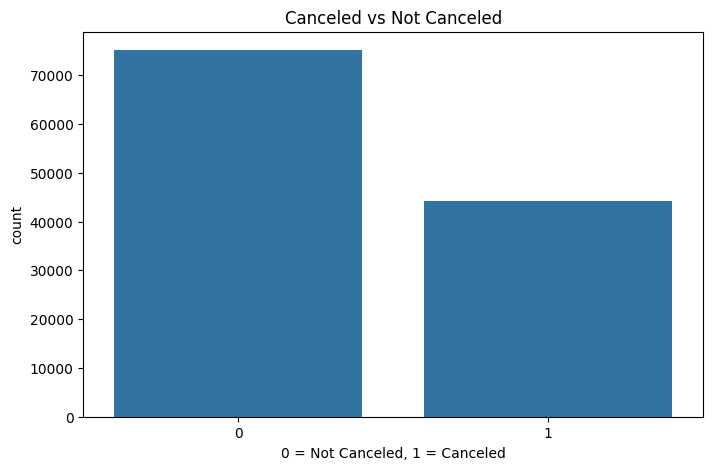

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_canceled', data=df)
plt.title("Canceled vs Not Canceled")
plt.xlabel("0 = Not Canceled, 1 = Canceled")
plt.show()

# the figure above tells us that roughly 37% of bookings get canceled which is actually a high cancellation rate, and that makes this a very real and important problem for hotels to predict

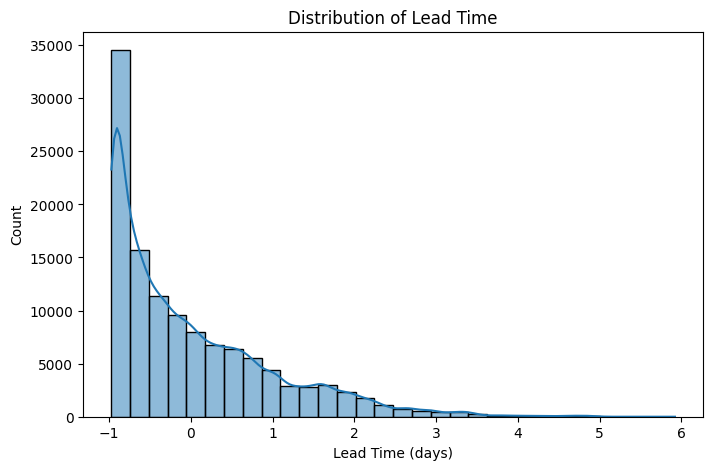

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df['lead_time'], bins=30, kde=True)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.show()

# for this one it shows Most bookings have a very short lead time, people mostly book close to their arrival date

### The negative values on x-axis are because we scaled lead_time, so -1 doesn't mean negative days, it's just the scaled version of small lead time values

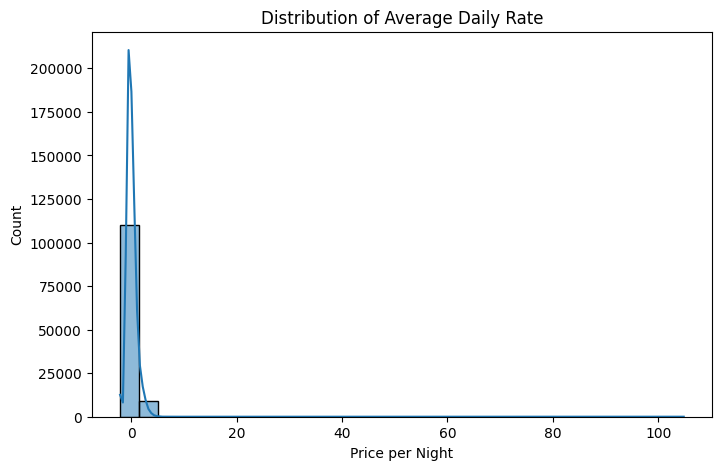

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df['adr'], bins=30, kde=True)
plt.title("Distribution of Average Daily Rate")
plt.xlabel("Price per Night")
plt.show()

### Not the most readable plot because of scaling, but it still shows that most bookings fall in a similar price range with a few very expensive outliers

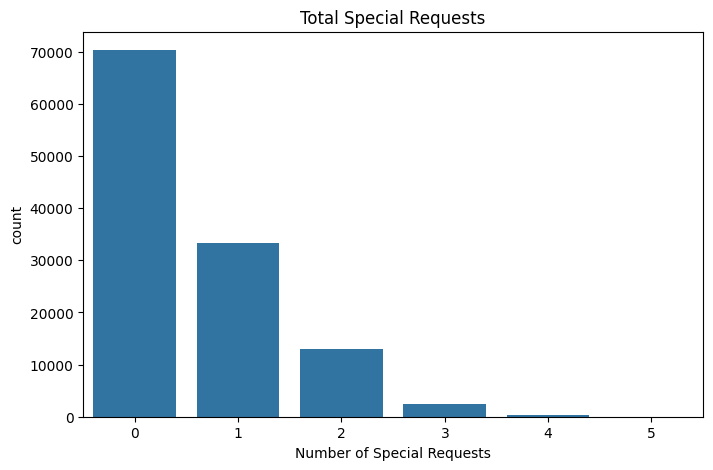

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='total_of_special_requests', data=df)
plt.title("Total Special Requests")
plt.xlabel("Number of Special Requests")
plt.show()

### the majority of people have no special requests, which makes our has_special_requests cols more valuable, because  most guests = 0, which means the ones who DO make requests are a smaller but important group that's less likely to cancel 

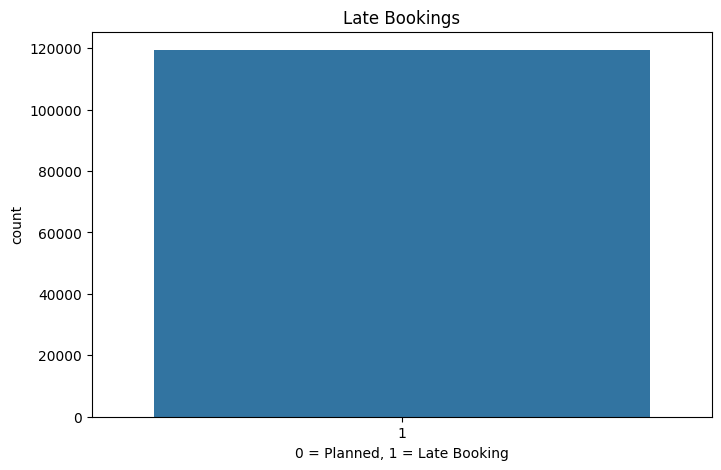

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_late_booking', data=df)
plt.title("Late Bookings")
plt.xlabel("0 = Planned, 1 = Late Booking")
plt.show()

### problem here cause we scaled then created new column with column that was already scaled, shall be fixed tho

In [22]:
# this will tell us what 7 days looks like after scaling
scaler.transform([[7, 0, 0, 0]])[0][0]

c:\myanaconda\envs\M2d_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(-0.907814066113084)

In [23]:
# recreate is_late_booking with the correct scaled threshold
df['is_late_booking'] = (df['lead_time'] < -0.9078).astype(int)

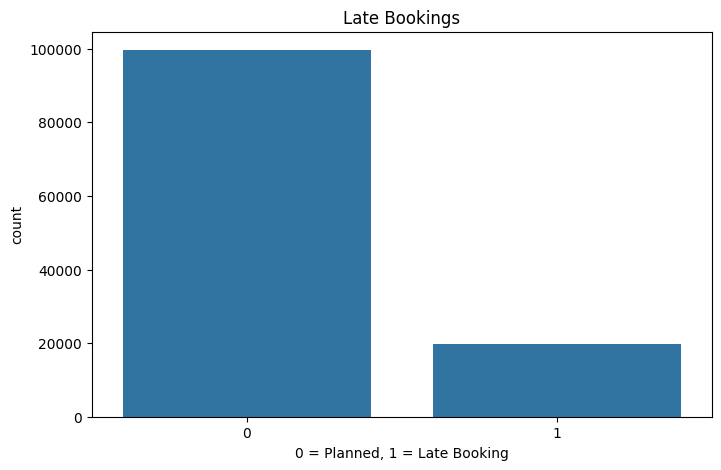

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_late_booking', data=df)
plt.title("Late Bookings")
plt.xlabel("0 = Planned, 1 = Late Booking")
plt.show()

## now this makes more sense
### ~100,000 bookings were planned (booked more than 7 days in advance)
### ~20,000 bookings were late (booked less than 7 days before arrival)
#### So most guests plan their bookings ahead of time, and only a small portion book last minute 

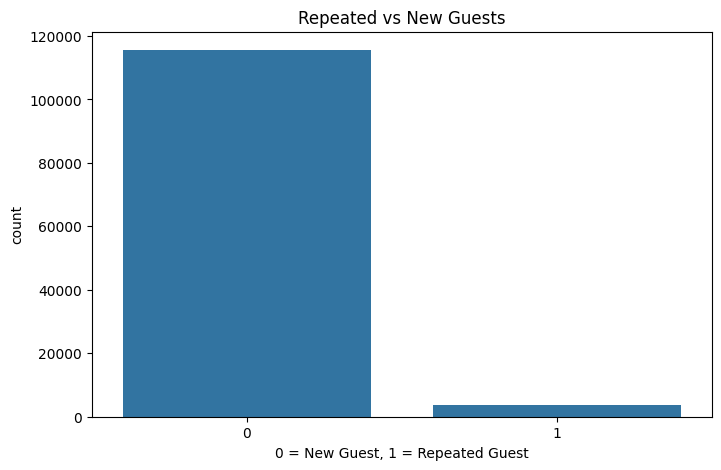

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_repeated_guest', data=df)
plt.title("Repeated vs New Guests")
plt.xlabel("0 = New Guest, 1 = Repeated Guest")
plt.show()

### So the vast majority of bookings are from new customers This makes sense for hotels most people don't stay at the same hotel repeatedl
### but still tell us that the very few of the repeated guests are less likely to cancel their booking

# now Bivariate analysis

### to explain what Bivariate analysis means, its simply relation between  two columns at the same time, so Unlike univariate analysis where we looked at each column alone, here we want to see how each feature interacts with our target column is_canceled

### and the reason we do it is, it helps us understand which features have a strong influence on whether a booking gets canceled or not, and gives us a better idea of what the model will rely on when making predictions

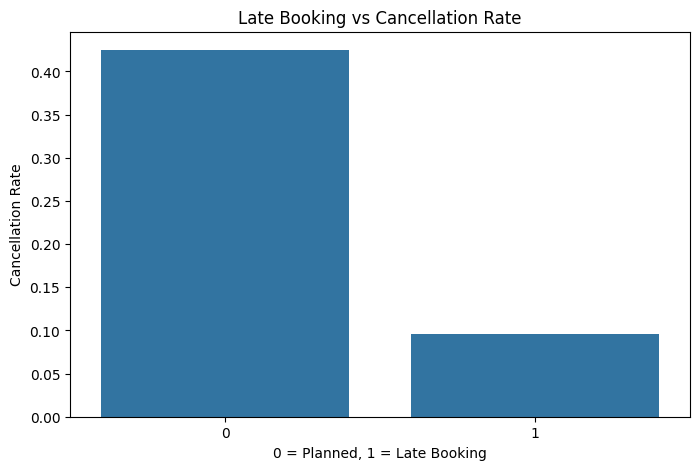

In [26]:
# 1. do late bookers cancel less than planned bookers?
plt.figure(figsize=(8, 5))
sns.barplot(x='is_late_booking', y='is_canceled', data=df, errorbar=None)
plt.title("Late Booking vs Cancellation Rate")
plt.xlabel("0 = Planned, 1 = Late Booking")
plt.ylabel("Cancellation Rate")
plt.show()

### good sign here 

### Planned bookings (0) → ~42% cancellation rate
### Late bookings (1) → only ~10% cancellation rate

### this confirms what i assumed earlier, people who book last minute are much less likely to cancel because they're clearly committed to their trip

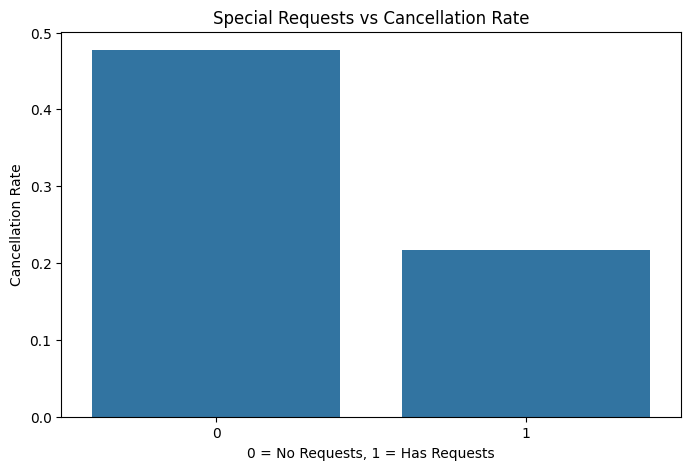

In [27]:
# 2. do guests with special requests cancel less?
plt.figure(figsize=(8, 5))
sns.barplot(x='has_special_requests', y='is_canceled', data=df, errorbar=None)
plt.title("Special Requests vs Cancellation Rate")
plt.xlabel("0 = No Requests, 1 = Has Requests")
plt.ylabel("Cancellation Rate")
plt.show()

### again confirms what i said, people with special requets are much more likely to show up 

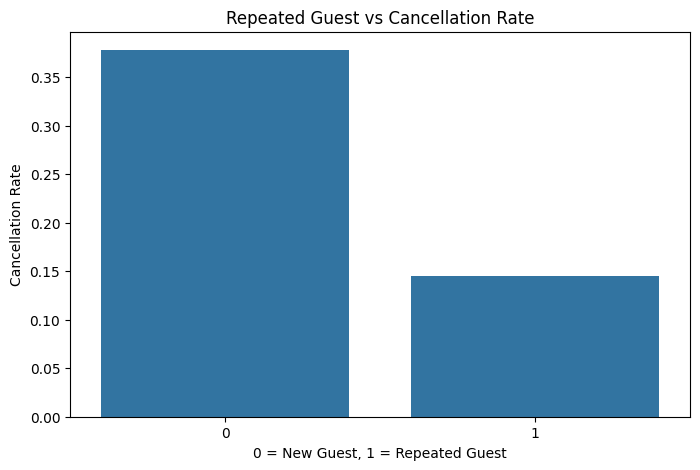

In [28]:
# 3. do repeated guests cancel less?
plt.figure(figsize=(8, 5))
sns.barplot(x='is_repeated_guest', y='is_canceled', data=df, errorbar=None)
plt.title("Repeated Guest vs Cancellation Rate")
plt.xlabel("0 = New Guest, 1 = Repeated Guest")
plt.ylabel("Cancellation Rate")
plt.show()

### another strong signal that repeated customers dont cancel their booking

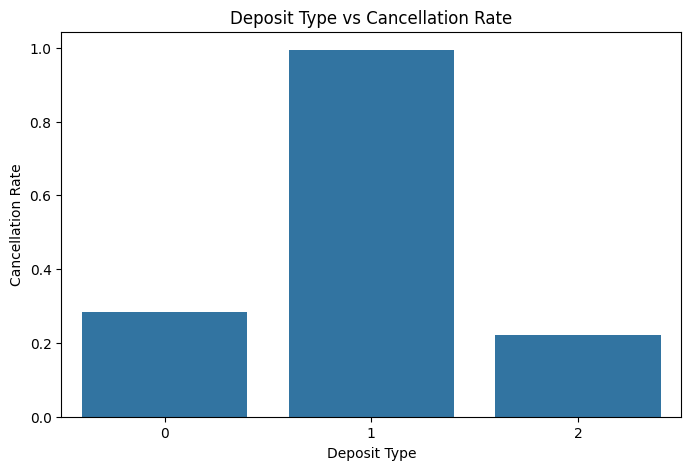

In [29]:
# 4. does deposit type affect cancellation?
plt.figure(figsize=(8, 5))
sns.barplot(x='deposit_type', y='is_canceled', data=df, errorbar=None)
plt.title("Deposit Type vs Cancellation Rate")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")
plt.show()

### okay there will be some explantion needed here so stay with me, now we scaled the deposit type so 0 = No Deposit → guest paid nothing upfront, 1 = Non Refund → guest paid and cannot get money back, 2 = Refundable → guest paid but can get money back

### now the plot shows the type 1 has 100% cancellation rate and that makes totally no sense cause i would assume if i paid to hotel and i cant get my money back, then i would def show up, but the paying always have missed up data specially for business model like hotels, cause the it could have been done through 3rd party like like ( booking or trivago), and this leaves us with many options, like maybe the guest paid and canceled through 3rd party and the 3rd part took the loss and sent money for both the hotel and the guest after he cancelled

### So the ~100% cancellation rate for Non Refund bookings is real in the data but the reason behind it is more complex than it looks in real life 

### but now we know that this column is not really reliable and we should drop when we are building the model

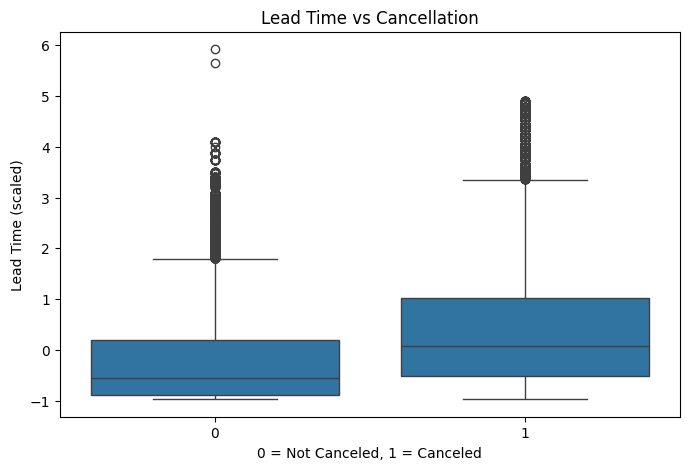

In [30]:
# 5. does lead time affect cancellation rate?
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.xlabel("0 = Not Canceled, 1 = Canceled")
plt.ylabel("Lead Time (scaled)")
plt.show()

### Not Canceled (0) → lead time is mostly low (box sits below 0)

### Canceled (1) → lead time is higher (box sits above 0)

### This confirms my theory theory the more days in advance someone books, the more likely they are to cancel because they have more time to change their mind

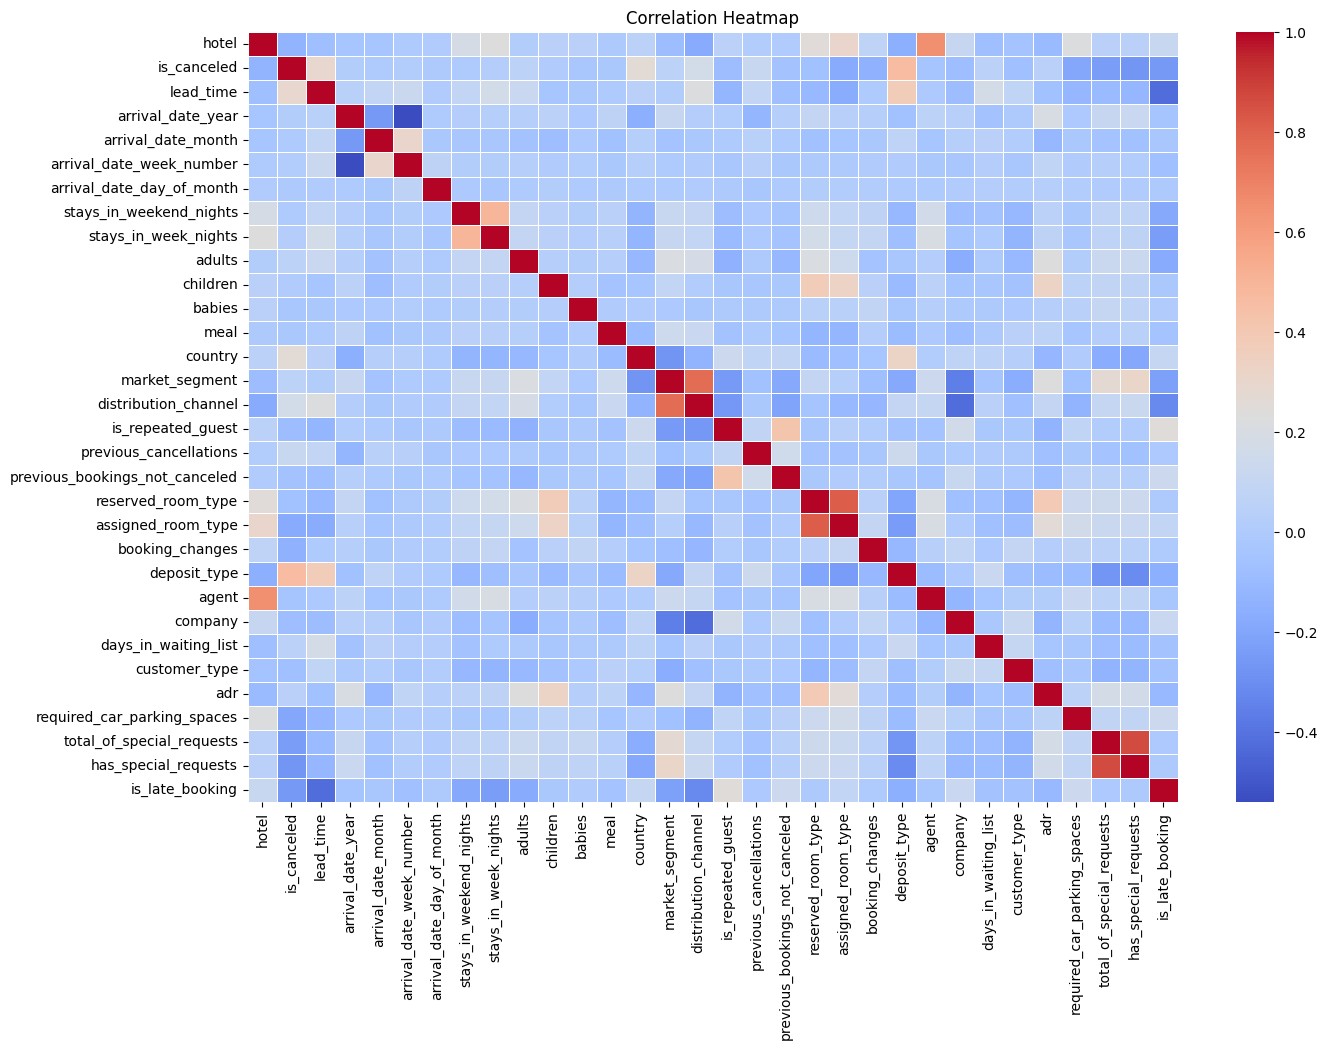

In [31]:
# now we will do a heatmap that shows us how strongly each feature is related to another
# values close to 1 or -1 mean strong relationship
# values close to 0 mean weak or no relationship

plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [32]:
# show exact correlation values with is_canceled
df.corr()['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
deposit_type                      0.468634
lead_time                         0.293123
country                           0.264738
distribution_channel              0.167600
previous_cancellations            0.110133
adults                            0.060017
market_segment                    0.059338
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005036
arrival_date_month               -0.001491
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
meal                             -0.017678
babies                           -0.032491
agent                            -0.046529
previous_bookings_not_canceled   -0.057358
reserved_room_type               -0.061282
customer_type                    -0.068140
company    

### the numbers above shows us that the top 3 relation with is canceled is deposit_type, has_special_requests, is_late_booking, but we are going to drop deposit_type soon

# Preparing Data for ML
## In this step we prepare our data to be fed into the machine learning models, We will separate our data into two parts 
## X which contains all the input features the model will learn from, and y which is our target column is_canceled that the model is trying to predict

### let's not forget dropping deposit_type as well

In [33]:
# dropping deposit_type because it was misleading in our analysis
df = df.drop(columns=['deposit_type'])

# y is what we want to predict
y = df['is_canceled']

# X is everything the model will learn from except the target column
X = df.drop(columns=['is_canceled'])

# confirm shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119390, 30)
y shape: (119390,)


## Train/Test Split

In [34]:
# splitting data into 80% training and 20% testing
# random_state=42 ensures we get the same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (95512, 30)
X_test shape: (23878, 30)
y_train shape: (95512,)
y_test shape: (23878,)


## Logistic Regression

### since in our case the outcome to predict is  classification and that output should be 0 or 1

### logistic Regression will be simplest classification model we will try ( Despite its name it is not used for regression, it is used for classification problems )

In [35]:
# building the model with saga solver which handles large datasets better
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_mad = LogisticRegression(max_iter=5000, random_state=42, solver='saga')

# training the model
lr_mad.fit(X_train, y_train)

# making predictions
lr_mad_pred = lr_mad.predict(X_test)

# evaluating the model
print("Logistic Regression Results:")
print("Accuracy:", round(accuracy_score(y_test, lr_mad_pred), 3))
print("Precision:", round(precision_score(y_test, lr_mad_pred), 3))
print("Recall:", round(recall_score(y_test, lr_mad_pred), 3))
print("F1 Score:", round(f1_score(y_test, lr_mad_pred), 3))

Logistic Regression Results:
Accuracy: 0.794
Precision: 0.76
Recall: 0.658
F1 Score: 0.706


c:\myanaconda\envs\M2d_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

# building the model
rf_mad = RandomForestClassifier(n_estimators=100, random_state=42)

# training the model
rf_mad.fit(X_train, y_train)

# making predictions
rf_mad_pred = rf_mad.predict(X_test)

# evaluating the model
print("Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, rf_mad_pred), 3))
print("Precision:", round(precision_score(y_test, rf_mad_pred), 3))
print("Recall:", round(recall_score(y_test, rf_mad_pred), 3))
print("F1 Score:", round(f1_score(y_test, rf_mad_pred), 3))

Random Forest Results:
Accuracy: 0.899
Precision: 0.894
Recall: 0.831
F1 Score: 0.861


## XGBoost

In [37]:
from xgboost import XGBClassifier

# building the model
xgb_mad = XGBClassifier(random_state=42, eval_metric='logloss')

# training the model
xgb_mad.fit(X_train, y_train)

# making predictions
xgb_mad_pred = xgb_mad.predict(X_test)

# evaluating the model
print("XGBoost Results:")
print("Accuracy:", round(accuracy_score(y_test, xgb_mad_pred), 3))
print("Precision:", round(precision_score(y_test, xgb_mad_pred), 3))
print("Recall:", round(recall_score(y_test, xgb_mad_pred), 3))
print("F1 Score:", round(f1_score(y_test, xgb_mad_pred), 3))

XGBoost Results:
Accuracy: 0.885
Precision: 0.862
Recall: 0.826
F1 Score: 0.844


### Among the three models tested, Random Forest achieved the best results across all metrics
### This is mainly because Random Forest builds 100 decision trees independently and combines their predictions through voting
### Each tree sees a different random portion of the data, and by voting together they reduce individual mistakes and produce a more accurate final answer
### This makes it far more powerful than Logistic Regression which relies on a single simple decision boundary, and slightly better than XGBoost which also builds trees but in a sequential rather than independent manner

### Now we Compare the Models Visually

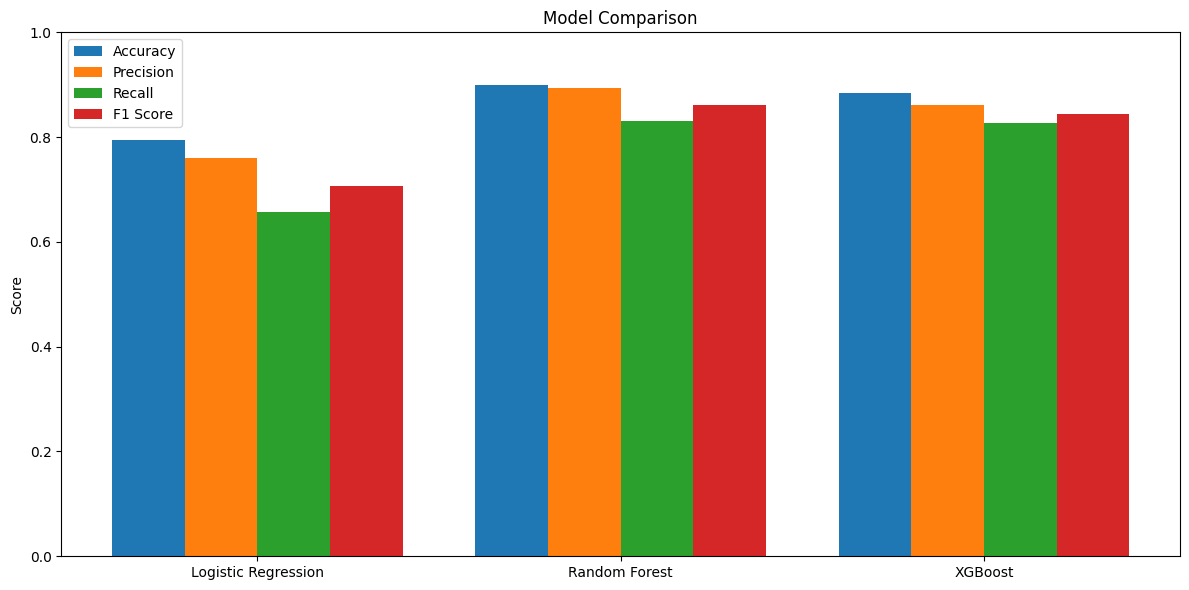

In [38]:
# a bar chart to compare all 3 models side by side
# so we can clearly see which model performed best

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [0.794, 0.899, 0.885]
precision = [0.760, 0.894, 0.862]
recall = [0.658, 0.831, 0.826]
f1 = [0.706, 0.861, 0.844]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

### Logistic Regression → lowest across all metrics
### Random Forest → highest across all metrics 
### XGBoost → close second but Random Forest still wins

### Since Random Forest was our best model, we will now try to make it even better through a process called hyperparameter tuning
### by default the model uses basic settings, but by trying different combinations of settings we can find the ones that give us the best possible results
### We will use a technique called GridSearchCV which automatically tries all the combinations we give it and tells us which one performed best using K-Fold Cross Validation to make sure the results are reliable

In [39]:
from sklearn.model_selection import GridSearchCV

# the settings we want to try
# reduced combinations to keep training time reasonable
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

# GridSearchCV will try all combinations using K-Fold Cross Validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# training
grid_search.fit(X_train, y_train)

# best settings found
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 3))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.836


### now since we know best parameters we rebuild random forest model

In [40]:
# rebuilding Random Forest with the best parameters found
rf_mad = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

# training
rf_mad.fit(X_train, y_train)

# making predictions
rf_mad_pred = rf_mad.predict(X_test)

# evaluating
print("Tuned Random Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, rf_mad_pred), 3))
print("Precision:", round(precision_score(y_test, rf_mad_pred), 3))
print("Recall:", round(recall_score(y_test, rf_mad_pred), 3))
print("F1 Score:", round(f1_score(y_test, rf_mad_pred), 3))

Tuned Random Forest Results:
Accuracy: 0.89
Precision: 0.886
Recall: 0.812
F1 Score: 0.847


### well it comes out the default settings we already pretty optimal for this dataset
### but at least we gave it a try, we stick with the original settings

In [41]:
# going back to original Random Forest settings since they performed better
rf_mad = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mad.fit(X_train, y_train)
rf_mad_pred = rf_mad.predict(X_test)

### Now that we have our best model, we will evaluate it more deeply using two additional tools. The first is a Confusion Matrix which shows us exactly how many bookings the model predicted correctly and incorrectly, broken down by canceled and not canceled

### The second is a ROC-AUC curve which shows how well the model can distinguish between a canceled and not canceled booking, the closer the score is to 1.0 the better the model is at telling them apart

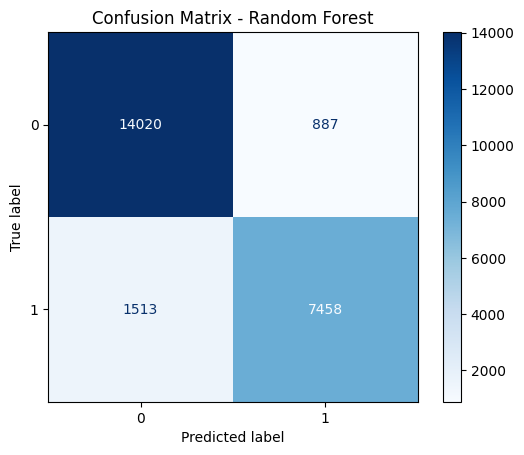

In [42]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# confusion matrix
cm = confusion_matrix(y_test, rf_mad_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

### for confusion matrix 
### 14020 → correctly predicted NOT canceled
### 7458 → correctly predicted canceled
### 887 → predicted not canceled but actually canceled
### 1513 → predicted canceled but actually not canceled

### so out of 23,878 predictions it got 21,478 out right 

## Now the ROC-AUC curve

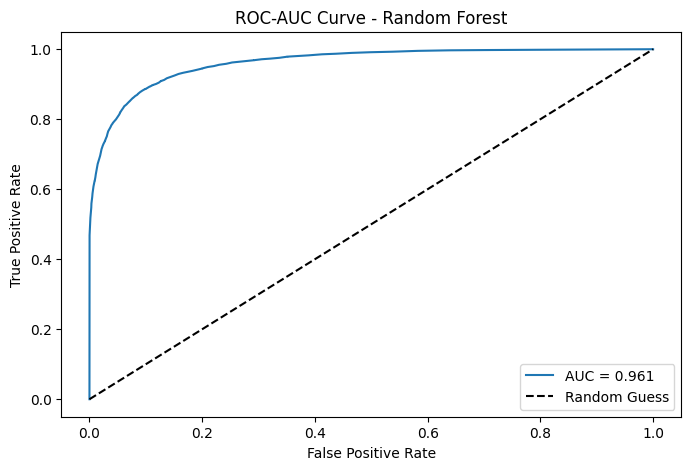

In [43]:
# ROC-AUC curve
rf_mad_proba = rf_mad.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, rf_mad_proba)
auc_score = roc_auc_score(y_test, rf_mad_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'AUC = {round(auc_score, 3)}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title("ROC-AUC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### the auc is 0.961 which is almost 1.0 so its pretty good

### Now its time to save the model and all the preprocessing tools we used during training

### This is important because when someone uses the app, the new data they enter must go through the exact same scaling and encoding we applied during training

###  If we don't save these tools and reuse them, the model will receive data in a different format than what it was trained on and will give wrong predictions

In [44]:
import joblib

# saving the trained Random Forest model
joblib.dump(rf_mad, 'rf_mad_model.pkl')

# saving the scaler so new data gets scaled the same way
joblib.dump(scaler, 'scaler_mad.pkl')

# saving the label encoder so new data gets encoded the same way
joblib.dump(le, 'le_mad.pkl')

print("Model and preprocessing tools saved successfully!")

Model and preprocessing tools saved successfully!


# Streamlit app

## now its time to build streamlit app for our project
### what will the app have:
### Title and description of the app
### Input fields for the user to enter booking details
### Predict button that runs the model
### Result showing whether the booking will be canceled or not
### The inputs we'll ask the user for:
### lead_time: how many days in advance they booked
### is_repeated_guest: are they a returning guest?
### has_special_requests: do they have special requests?
### is_late_booking: did they book last minute?
### total_of_special_requests: how many special requests?
### adr: average price per night
### adults: number of adults
### children: number of children
### hotel: City or Resort hotel
### market_segment: how they booked (Online, Direct, etc.)
#### we will fill the rest of features with mean or mode values from the training data automatically

In [49]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# page config
st.set_page_config(
    page_title="Hotel Booking Predictor",
    page_icon="🏨",
    layout="centered"
)

# custom CSS styling
st.markdown("""
    <style>
    .stApp {
        background: linear-gradient(135deg, #1c1c1c, #2b2b2b, #3a3a3a);
        color: #f0f0f0;
    }
    .stButton>button {
        background-color: #c0392b;
        color: white;
        border-radius: 10px;
        height: 50px;
        width: 100%;
        font-size: 18px;
        font-weight: bold;
        border: none;
    }
    .stButton>button:hover {
        background-color: #a93226;
    }
    .stSelectbox label, .stSlider label, .stNumberInput label {
        color: #f0f0f0 !important;
        font-size: 15px;
    }
    h1, h2, h3 {
        color: #f0f0f0 !important;
    }
    .stMarkdown p {
        color: #cccccc !important;
    }
    </style>
""", unsafe_allow_html=True)

# loading the saved model and preprocessing tools
rf_mad_model = joblib.load('rf_mad_model.pkl')
scaler_mad = joblib.load('scaler_mad.pkl')

# app title and description
st.title("Hotel Booking Cancellation Predictor")
st.markdown("Fill in the booking details below to predict whether the booking will be canceled or not.")
st.markdown("---")

# user inputs
st.subheader("Booking Details")

col1, col2 = st.columns(2)

with col1:
    hotel = st.selectbox("Hotel Type", ["City Hotel", "Resort Hotel"])
    lead_time = st.slider("Lead Time (days in advance)", 0, 700, 50)
    adults = st.number_input("Number of Adults", 1, 10, 2)
    children = st.number_input("Number of Children", 0, 10, 0)

with col2:
    adr = st.number_input("Average Price Per Night", 0, 1000, 100)
    is_repeated_guest = st.selectbox("Returning Guest?", ["No", "Yes"])
    total_of_special_requests = st.slider("Number of Special Requests", 0, 5, 0)
    market_segment = st.selectbox("Booking Channel", ["Online TA", "Offline TA/TO", "Direct", "Corporate", "Groups"])

st.markdown("---")

# converting inputs
hotel_encoded = 0 if hotel == "City Hotel" else 1
is_repeated_guest_encoded = 1 if is_repeated_guest == "Yes" else 0
has_special_requests = 1 if total_of_special_requests > 0 else 0
is_late_booking = 1 if lead_time < 7 else 0
market_segment_map = {"Online TA": 4, "Offline TA/TO": 3, "Direct": 2, "Corporate": 1, "Groups": 0}
market_segment_encoded = market_segment_map[market_segment]

# building the full input using mean values for hidden features
input_data = pd.DataFrame([{
    'hotel': hotel_encoded,
    'lead_time': lead_time,
    'arrival_date_year': 2016,
    'arrival_date_month': 5.50,
    'arrival_date_week_number': 27.17,
    'arrival_date_day_of_month': 15.78,
    'stays_in_weekend_nights': 0.93,
    'stays_in_week_nights': 2.50,
    'adults': adults,
    'children': children,
    'babies': 0.01,
    'meal': 0.56,
    'country': 93.26,
    'market_segment': market_segment_encoded,
    'distribution_channel': 2.59,
    'is_repeated_guest': is_repeated_guest_encoded,
    'previous_cancellations': 0.09,
    'previous_bookings_not_canceled': 0.13,
    'reserved_room_type': 0.99,
    'assigned_room_type': 1.33,
    'booking_changes': 0.22,
    'agent': 74.76,
    'company': 10.79,
    'days_in_waiting_list': 2.34,
    'customer_type': 2.14,
    'adr': adr,
    'required_car_parking_spaces': 0.06,
    'total_of_special_requests': total_of_special_requests,
    'has_special_requests': has_special_requests,
    'is_late_booking': is_late_booking
}])

# scaling the same columns we scaled during training
scaled_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights']
input_data[scaled_cols] = scaler_mad.transform(input_data[scaled_cols])

# predict button
if st.button("Predict"):
    prediction = rf_mad_model.predict(input_data)[0]
    probability = rf_mad_model.predict_proba(input_data)[0]

    if prediction == 1:
        st.error(f"This booking is likely to be CANCELED: Confidence: {round(probability[1]*100, 1)}%")
    else:
        st.success(f"This booking is likely to SHOW UP: Confidence: {round(probability[0]*100, 1)}%")

Overwriting app.py


In [46]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
xgboost
joblib

Overwriting requirements.txt


In [47]:
# save model with compression to reduce file size
joblib.dump(rf_mad, 'rf_mad_model.pkl', compress=3)

['rf_mad_model.pkl']

In [48]:
# get the mean values of all columns to use as better defaults
X_train.mean().round(2)

hotel                                0.33
lead_time                           -0.00
arrival_date_year                 2016.16
arrival_date_month                   5.50
arrival_date_week_number            27.17
arrival_date_day_of_month           15.78
stays_in_weekend_nights             -0.00
stays_in_week_nights                 0.00
adults                               1.86
children                             0.10
babies                               0.01
meal                                 0.56
country                             93.26
market_segment                       4.93
distribution_channel                 2.59
is_repeated_guest                    0.03
previous_cancellations               0.09
previous_bookings_not_canceled       0.13
reserved_room_type                   0.99
assigned_room_type                   1.33
booking_changes                      0.22
agent                               74.76
company                             10.79
days_in_waiting_list              